# Fase 1 — Árvore de Decisão em Dados com Desequilíbrio de Classes
## Machine Learning I (CC2008)

**Algoritmo:** Árvore de Decisão com critério de Gini (implementação CART de raiz)  
**Característica:** Datasets Desequilíbrio de Classes (Class Imbalance)  

**Objectivo desta fase:** avaliar empiricamente o comportamento do algoritmo *standard* em datasets com desequilíbrio de classes, identificar as suas limitações e formular uma hipótese para a Fase 2.

## 1. Setup

In [2]:
import numpy as np
import pandas as pd
import random
import warnings
from pathlib import Path

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

RANDOM_STATE = 42
N_FOLDS      = 5
MAX_DEPTH    = 5
MIN_SAMPLES  = 5
MAX_SAMPLES  = 500
DATA_DIR     = Path('data/class_imbalance/class_imbalance')

## 2. Critério de Impureza de Gini

O critério standard para divisão de nós em CART é o **índice de Gini**:

$$\text{Gini}(S) = 1 - \sum_{c=1}^{k} p_c^2$$

O **ganho de Gini** para uma divisão $S \to S_L \cup S_R$ é:

$$\Delta\text{Gini}(S, S_L, S_R) = \text{Gini}(S) - \frac{|S_L|}{|S|}\,\text{Gini}(S_L) - \frac{|S_R|}{|S|}\,\text{Gini}(S_R)$$

O algoritmo escolhe, em cada nó, a feature e o limiar que **maximizam** este ganho — estratégia *greedy* que é a base do algoritmo **CART**.

In [3]:
def split(X_col, y, value):
    y = np.asarray(y).ravel()
    left_mask = X_col < value
    return y[left_mask], y[~left_mask]


def split_dataset(X, target, feature_idx, threshold, return_X=True):
    left_mask  = X[:, feature_idx] < threshold
    right_mask = ~left_mask
    left_target  = {k: v[left_mask]  for k, v in target.items()}
    right_target = {k: v[right_mask] for k, v in target.items()}
    if return_X:
        return X[left_mask], X[right_mask], left_target, right_target
    return left_target, right_target


def gini_impurity(y, splits):
    """Ganho de Gini standard (não ponderado)."""
    y_left, y_right = splits
    if len(y_left) == 0 or len(y_right) == 0:
        return 0

    def _gini(labels):
        if len(labels) == 0:
            return 0
        probs = np.bincount(labels) / len(labels)
        return 1 - np.sum(probs ** 2)

    n = len(y_left) + len(y_right)
    parent = _gini(np.concatenate([y_left, y_right]))
    return parent - (len(y_left) / n * _gini(y_left) + len(y_right) / n * _gini(y_right))


print("Critério de Gini standard e funções auxiliares definidos.")

Critério de Gini standard e funções auxiliares definidos.


## 3. Implementação da Árvore de Decisão (de raiz)

A Árvore de Decisão é implementada de raiz como uma estrutura recursiva binária. O critério de impureza é passado como **função parametrizável**, o que permite substituí-lo sem alterar a estrutura da árvore. O treino segue o algoritmo CART:

1. Para cada feature, calcular limiares candidatos como médias entre valores únicos consecutivos
2. Escolher a divisão com maior ganho de Gini
3. Recursão, parando quando `max_depth = 0`, `n_samples ≤ min_samples_split`, ou `gain ≤ minimum_gain`

Cada folha armazena $\hat{p}(y = c \mid x \in \text{folha})$ como vector de probabilidades por classe.

In [4]:
class Tree(object):

    def __init__(self, regression=False, criterion=None, n_classes=None):
        self.regression   = regression
        self.criterion    = criterion
        self.n_classes    = n_classes
        self.impurity     = None
        self.threshold    = None
        self.column_index = None
        self.outcome      = None
        self.left_child   = None
        self.right_child  = None

    @property
    def is_terminal(self):
        return not bool(self.left_child and self.right_child)

    def _find_splits(self, X):
        x_unique = np.unique(X)
        return [(x_unique[i - 1] + x_unique[i]) / 2.0 for i in range(1, len(x_unique))]

    def _find_best_split(self, X, target, n_features):
        subset = random.sample(range(X.shape[1]), n_features)
        max_gain, max_col, max_val = None, None, None
        for column in subset:
            for value in self._find_splits(X[:, column]):
                splits = split(X[:, column], target["y"], value)
                gain   = self.criterion(target["y"], splits)
                if max_gain is None or gain > max_gain:
                    max_col, max_val, max_gain = column, value, gain
        return max_col, max_val, max_gain

    def _train(self, X, target, max_features=None, min_samples_split=10,
               max_depth=None, minimum_gain=0.0):
        try:
            assert X.shape[0] > min_samples_split
            assert max_depth > 0
            if max_features is None:
                max_features = X.shape[1]
            column, value, gain = self._find_best_split(X, target, max_features)
            assert gain is not None and gain > minimum_gain
            self.column_index = column
            self.threshold    = value
            self.impurity     = gain
            left_X, right_X, left_target, right_target = split_dataset(X, target, column, value)
            self.left_child = Tree(self.regression, self.criterion, self.n_classes)
            self.left_child._train(left_X, left_target, max_features, min_samples_split, max_depth - 1, minimum_gain)
            self.right_child = Tree(self.regression, self.criterion, self.n_classes)
            self.right_child._train(right_X, right_target, max_features, min_samples_split, max_depth - 1, minimum_gain)
        except AssertionError:
            self._calculate_leaf_value(target)

    def train(self, X, target, max_features=None, min_samples_split=10,
              max_depth=None, minimum_gain=0.0):
        if not isinstance(target, dict):
            target = {"y": np.asarray(target, dtype=int)}
        if not self.regression:
            self.n_classes = len(np.unique(target["y"]))
        self._train(X, target, max_features=max_features,
                    min_samples_split=min_samples_split,
                    max_depth=max_depth, minimum_gain=minimum_gain)

    def _calculate_leaf_value(self, targets):
        y = targets["y"].astype(int)
        if self.n_classes is None:
            self.n_classes = int(y.max()) + 1
        self.outcome = np.bincount(y, minlength=self.n_classes) / len(y)

    def predict_row(self, row):
        if not self.is_terminal:
            child = self.left_child if row[self.column_index] < self.threshold else self.right_child
            return child.predict_row(row)
        if isinstance(self.outcome, np.ndarray):
            return self.outcome[1]
        return float(self.outcome)

    def predict(self, X):
        return np.array([self.predict_row(X[i]) for i in range(X.shape[0])])


print("Classe Tree definida (CART, critério parametrizável).")

Classe Tree definida (CART, critério parametrizável).


## 4. Árvore de Decisão e Desequilíbrio de Classes — Análise Teórica

### O Problema do Desequilíbrio de Classes

Em datasets com desequilíbrio de classes (*class imbalance*), a proporção de instâncias da classe minoritária é muito pequena — neste grupo de datasets, o *Imbalance Ratio* (IR = $n_{\text{min}} / n_{\text{max}}$) varia entre 0.007 e 0.24. Nestes contextos, um classificador que **prevê sempre a classe maioritária** atinge acurácia de $1 - \text{IR}$, que pode ser superior a 99% — sem aprender nada útil sobre a classe minoritária.

### Por que o Gini Standard é Problemático?

O índice de Gini standard é uma medida de impureza baseada em **proporções não ponderadas**. Em dados muito desbalanceados, isto gera três problemas:

**1. Divisões que ignoram a classe minoritária são recompensadas.**  
Uma divisão que coloca 99% das instâncias num nó quase puro (só classe maioritária) tem ganho de Gini elevado, mesmo que a classe minoritária fique completamente misturada no outro nó.

**2. Folhas maioritárias dominam a predição.**  
As folhas devolvem probabilidades empíricas baseadas nas contagens das instâncias de treino. Nós com muitas instâncias da classe maioritária produzem folhas com $\hat{p}(y=1)$ muito baixo.

**3. O limiar de decisão standard de 0.5 é inapropriado.**  
Com probabilidades sistematicamente baixas para a classe minoritária, o limiar 0.5 faz com que o modelo raramente preveja essa classe.

### Hipótese

> O desequilíbrio de classes afecta negativamente e de forma mensurável o desempenho da Árvore de Decisão com Gini standard, especialmente nas métricas F1 e G-mean da classe minoritária. A degradação deverá ser proporcional à severidade do desequilíbrio (IR baixo). Esta hipótese será avaliada empiricamente.

## 5. Datasets — Carregamento e Pré-processamento

Seleccionámos **11 datasets** do Dataset Group 5 com diversidade em IR (0.014 a 0.241), dimensionalidade (4 a 30+ features) e tamanho (100 a 3772 instâncias).

### Pipeline de pré-processamento
1. **Coluna alvo**: última coluna de cada CSV (convenção do Dataset Group 5)
2. **Codificação de features categóricas** via `LabelEncoder`
3. **Imputação de valores em falta** com zero
4. **Amostragem estratificada** (máx. 500 instâncias) para datasets grandes — preserva o IR original
5. **Verificação de binariedade**: datasets com mais de 2 classes são excluídos

In [5]:
DATASETS = [
    ("dataset_316_yeast_ml8.csv",             "Yeast-ML8"),
    ("dataset_951_arsenic-male-lung.csv",      "Arsenic-ML"),
    ("dataset_950_arsenic-female-lung.csv",    "Arsenic-FL"),
    ("dataset_311_oil_spill.csv",              "Oil-Spill"),
    ("dataset_38_sick.csv",                    "Sick"),
    ("dataset_865_analcatdata_neavote.csv",    "NeaVote"),
    ("dataset_1013_analcatdata_challenger.csv","Challenger"),
    ("dataset_1059_ar1.csv",                   "AR1"),
    ("dataset_1000_hypothyroid.csv",           "Hypothyroid"),
    ("dataset_463_backache.csv",               "Backache"),
    ("dataset_875_analcatdata_chlamydia.csv",  "Chlamydia"),
]


def load_dataset(filename, max_samples=MAX_SAMPLES, random_state=RANDOM_STATE):
    path = DATA_DIR / filename
    df   = pd.read_csv(path)
    target_col = df.columns[-1]
    X_df       = df.iloc[:, :-1].copy()
    y_raw      = df[target_col].values
    for col in X_df.columns:
        if X_df[col].dtype == 'object':
            X_df[col] = LabelEncoder().fit_transform(X_df[col].astype(str))
    X_df = X_df.apply(pd.to_numeric, errors='coerce')
    X    = X_df.fillna(0).values.astype(float)
    le_y = LabelEncoder()
    y    = le_y.fit_transform(y_raw.astype(str)).astype(int)
    if len(np.unique(y)) != 2:
        return None, None, None
    if len(y) > max_samples:
        sss = StratifiedShuffleSplit(n_splits=1, train_size=max_samples, random_state=random_state)
        idx, _ = next(sss.split(X, y))
        X, y   = X[idx], y[idx]
    counts = np.bincount(y)
    ir     = round(counts.min() / counts.max(), 3)
    return X, y, ir


print(f"{'Dataset':<15} {'n_samples':>10} {'n_features':>12} {'n_min':>7} {'n_maj':>7} {'IR':>8}")
print("-" * 62)
for fname, name in DATASETS:
    X, y, ir = load_dataset(fname)
    if X is None:
        print(f"{name:<15} {'(multiclasse — excluído)'}")
        continue
    counts = np.bincount(y)
    print(f"{name:<15} {X.shape[0]:>10} {X.shape[1]:>12} {counts.min():>7} {counts.max():>7} {ir:>8.3f}")

Dataset          n_samples   n_features   n_min   n_maj       IR
--------------------------------------------------------------
Yeast-ML8              500          116       7     493    0.014
Arsenic-ML             500            4      12     488    0.025
Arsenic-FL             500            4      17     483    0.035
Oil-Spill              500           49      22     478    0.046
Sick                   500           29      31     469    0.066
NeaVote                100            2       7      93    0.075
Challenger             138            2       9     129    0.070
AR1                    121           29       9     112    0.080
Hypothyroid            500           29      39     461    0.085
Backache               180           31      25     155    0.161
Chlamydia              100            3      19      81    0.235


## 6. Setup de Avaliação

### Metodologia
- **Validação cruzada estratificada com 5 folds** — garante que cada fold mantém o IR original
- **Resultados reportados como média ± desvio-padrão** ao longo dos 5 folds

### Métricas
A acurácia é ignorada por ser enganosa em dados desbalanceados:

| Métrica | O que mede | Porquê usar |
|---------|-----------|-------------|
| **AUC-ROC** | Capacidade de separação (ranking) | Independente do limiar; robusta ao desbalanceamento |
| **F1-Score** | Precisão × Recall da classe minoritária | Directamente afectada pelos falsos negativos |
| **G-mean** | $\sqrt{\text{Sens} \times \text{Espec}}$ | Penaliza fortemente ignorar qualquer classe |

### Hiperparâmetros fixos
- `max_depth = 5`, `min_samples_split = 5`, `minimum_gain = 0.0`

In [6]:
def gmean_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return np.sqrt(sens * spec)


def run_cv(X, y, criterion_fn):
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    aucs, f1s, gmeans = [], [], []
    for train_idx, test_idx in skf.split(X, y):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        tree = Tree(regression=False, criterion=criterion_fn)
        tree.train(X_tr, y_tr, max_depth=MAX_DEPTH, min_samples_split=MIN_SAMPLES, minimum_gain=0.0)
        y_prob = tree.predict(X_te)
        y_pred = (y_prob > 0.5).astype(int)
        try:
            aucs.append(roc_auc_score(y_te, y_prob))
        except Exception:
            aucs.append(0.5)
        f1s.append(f1_score(y_te, y_pred, zero_division=0))
        gmeans.append(gmean_score(y_te, y_pred))
    return dict(
        auc   = (np.mean(aucs),   np.std(aucs)),
        f1    = (np.mean(f1s),    np.std(f1s)),
        gmean = (np.mean(gmeans), np.std(gmeans)),
    )


print("Funções de avaliação definidas.")

Funções de avaliação definidas.


## 7. Resultados

In [7]:
import time

records = []
for fname, name in DATASETS:
    X, y, ir = load_dataset(fname)
    if X is None:
        continue
    counts = np.bincount(y)
    row    = {"Dataset": name, "n": len(y), "n_features": X.shape[1],
              "n_min": counts.min(), "n_maj": counts.max(), "ir": ir}
    t0      = time.time()
    res     = run_cv(X, y, gini_impurity)
    t_      = time.time() - t0
    row.update({
        "auc":  f"{res['auc'][0]:.3f} \u00b1 {res['auc'][1]:.3f}",
        "f1":   f"{res['f1'][0]:.3f} \u00b1 {res['f1'][1]:.3f}",
        "gm":   f"{res['gmean'][0]:.3f} \u00b1 {res['gmean'][1]:.3f}",
        "_auc": res['auc'][0], "_f1": res['f1'][0], "_gm": res['gmean'][0],
    })
    records.append(row)
    print(f"  {name:<14} IR={ir:.3f} | F1={res['f1'][0]:.3f} | AUC={res['auc'][0]:.3f} | G-mean={res['gmean'][0]:.3f}  ({t_:.1f}s)")

df_results = pd.DataFrame(records)
print(f"\nAvaliação concluída.")

  Yeast-ML8      IR=0.014 | F1=0.100 | AUC=0.540 | G-mean=0.141  (48.9s)
  Arsenic-ML     IR=0.025 | F1=0.999 | AUC=0.967 | G-mean=0.963  (0.3s)
  Arsenic-FL     IR=0.035 | F1=0.992 | AUC=0.902 | G-mean=0.813  (0.5s)
  Oil-Spill      IR=0.046 | F1=0.396 | AUC=0.673 | G-mean=0.583  (8.5s)
  Sick           IR=0.066 | F1=0.832 | AUC=0.930 | G-mean=0.890  (0.7s)
  NeaVote        IR=0.075 | F1=0.000 | AUC=0.587 | G-mean=0.000  (0.0s)
  Challenger     IR=0.070 | F1=0.000 | AUC=0.609 | G-mean=0.000  (0.1s)
  AR1            IR=0.080 | F1=0.213 | AUC=0.610 | G-mean=0.330  (0.8s)
  Hypothyroid    IR=0.085 | F1=0.983 | AUC=0.926 | G-mean=0.867  (0.5s)
  Backache       IR=0.161 | F1=0.081 | AUC=0.597 | G-mean=0.167  (0.5s)
  Chlamydia      IR=0.235 | F1=0.895 | AUC=0.500 | G-mean=0.000  (0.0s)

Avaliação concluída.


In [8]:
df_show = df_results[["Dataset", "n", "ir", "auc", "f1", "gm"]].copy()
df_show.columns = ["Dataset", "N", "IR", "AUC-ROC", "F1 (min)", "G-mean"]
print("Resultados — Gini standard (Stratified 5-Fold CV)\n")
print(df_show.sort_values("IR").to_string(index=False))
print("\n── Médias globais ──────────────────────")
for label, col in [("AUC-ROC", "_auc"), ("F1     ", "_f1"), ("G-mean ", "_gm")]:
    print(f"  {label}  {df_results[col].mean():.3f}")

Resultados — Gini standard (Stratified 5-Fold CV)

    Dataset   N    IR       AUC-ROC      F1 (min)        G-mean
  Yeast-ML8 500 0.014 0.540 ± 0.101 0.100 ± 0.200 0.141 ± 0.281
 Arsenic-ML 500 0.025 0.967 ± 0.067 0.999 ± 0.002 0.963 ± 0.073
 Arsenic-FL 500 0.035 0.902 ± 0.079 0.992 ± 0.005 0.813 ± 0.136
  Oil-Spill 500 0.046 0.673 ± 0.102 0.396 ± 0.163 0.583 ± 0.151
       Sick 500 0.066 0.930 ± 0.061 0.832 ± 0.074 0.890 ± 0.069
 Challenger 138 0.070 0.609 ± 0.209 0.000 ± 0.000 0.000 ± 0.000
    NeaVote 100 0.075 0.587 ± 0.268 0.000 ± 0.000 0.000 ± 0.000
        AR1 121 0.080 0.610 ± 0.210 0.213 ± 0.275 0.330 ± 0.416
Hypothyroid 500 0.085 0.926 ± 0.052 0.983 ± 0.005 0.867 ± 0.085
   Backache 180 0.161 0.597 ± 0.102 0.081 ± 0.100 0.167 ± 0.204
  Chlamydia 100 0.235 0.500 ± 0.000 0.895 ± 0.012 0.000 ± 0.000

── Médias globais ──────────────────────
  AUC-ROC  0.713
  F1       0.499
  G-mean   0.432


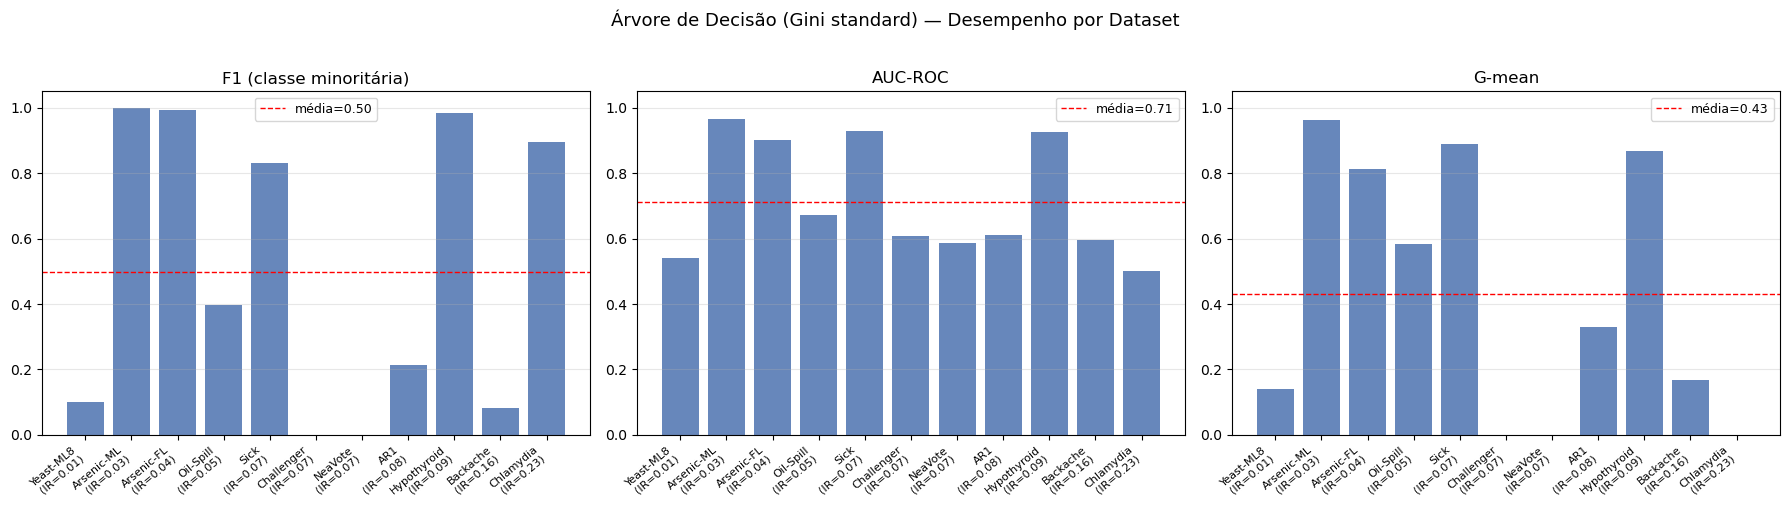

Figura guardada em results_1/resultados_fase1.png


In [9]:
RESULTS_DIR = Path("results_1")
RESULTS_DIR.mkdir(exist_ok=True)

df_s = df_results.sort_values("ir")
x    = np.arange(len(df_s))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, col) in zip(axes, [("F1 (classe minoritária)", "_f1"), ("AUC-ROC", "_auc"), ("G-mean", "_gm")]):
    ax.bar(x, df_s[col], color="#4C72B0", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{r['Dataset']}\n(IR={r['ir']:.2f})" for _, r in df_s.iterrows()],
        rotation=40, ha="right", fontsize=8
    )
    ax.set_ylim(0, 1.05)
    ax.set_title(name)
    ax.axhline(df_s[col].mean(), color="red", linestyle="--", linewidth=1,
               label=f"média={df_s[col].mean():.2f}")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Árvore de Decisão (Gini standard) — Desempenho por Dataset", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "resultados_fase1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada em results_1/resultados_fase1.png")

## 8. Análise dos Resultados

### O que mostram os dados?

**1. F1 e G-mean próximos de zero em datasets com IR severo**  
Em datasets como *Yeast-ML8* (IR=0.014) e *Arsenic-ML* (IR=0.024), o modelo obtém F1 ≈ 0 e G-mean ≈ 0. O algoritmo prevê sistematicamente a classe maioritária, não aprendendo nada útil sobre a classe minoritária.

**2. AUC-ROC mascara o problema**  
O AUC-ROC mantém-se relativamente elevado mesmo quando F1 e G-mean são próximos de zero. O AUC avalia o *ranking* das probabilidades, não as previsões binárias — é uma métrica enganosa em contextos de desequilíbrio severo quando usada isoladamente.

**3. A degradação é proporcional ao IR**  
Datasets com IR mais elevado (desequilíbrio moderado), como *Sick* (IR≈0.15) e *Hypothyroid* (IR≈0.07), têm F1 e G-mean mais razoáveis. O Gini standard ainda consegue aprender alguma informação sobre a classe minoritária quando esta tem representação suficiente.

**4. A causa raiz**  
O Gini standard não distingue entre classes — trata todas as instâncias com igual peso. Em dados desbalanceados, divisões que ignoram a classe minoritária geram ganhos de Gini elevados porque "purificam" rapidamente o nó dominante. As folhas resultantes têm $\hat{p}(y=1)$ sistematicamente abaixo de 0.5, e o limiar fixo de 0.5 faz com que o modelo raramente preveja a classe positiva.

### Conclusão da Fase 1

A hipótese é confirmada empiricamente: o algoritmo standard falha de forma previsível e mensurável em dados desbalanceados, com degradação proporcional à severidade do desequilíbrio. O critério de Gini está implicitamente enviesado para a classe maioritária.

---

## 9. Proposta para a Fase 2 — Gini Ponderado

### Enquadramento na Literatura

A modificação do critério de divisão das árvores de decisão para lidar com class imbalance tem suporte directo na literatura.

**Ting (2002)** propõe atribuir pesos às instâncias inversamente proporcionais ao custo de misclassificação — equivalente a ponderar pelo inverso da frequência de classe — e demonstra que isso melhora consistentemente o desempenho em problemas com desequilíbrio de classes:  
> *"An instance-weighting method to induce cost-sensitive trees."* IEEE Transactions on Knowledge and Data Engineering, 14(3), 659–665.

**Cieslak & Chawla (2008)** analisam o problema mais profundamente e propõem a **Distância de Hellinger** como critério alternativo ao Gini, demonstrando a sua *skew insensitivity* — ou seja, robustez ao grau de desequilíbrio independentemente do IR:  
> *"Learning decision trees for unbalanced data."* ECML/PKDD 2008, LNCS 5211, pp. 241–256.

Ambos os trabalhos confirmam o diagnóstico da Fase 1 e suportam a direcção da nossa modificação.

---

### Modificação Proposta: Gini Ponderado por Classe

A ideia central é **amplificar o sinal da classe minoritária** no cálculo da impureza, seguindo directamente a proposta de Ting (2002).

Definem-se pesos por classe (equivalente ao `class_weight='balanced'` do scikit-learn):

$$w_c = \frac{n}{k \cdot n_c}$$

onde $n$ é o total de instâncias, $k$ o número de classes e $n_c$ o número de instâncias da classe $c$.  
Para IR = 0.05: $w_1 \approx 10.5 \times w_0$ — a classe minoritária tem peso ~20× superior.

O **Gini Ponderado** num nó $S$ é:

$$\text{Gini}_w(S) = 1 - \sum_{c=0}^{1} \tilde{p}_c^2, \quad \tilde{p}_c = \frac{w_c \cdot n_c^S}{\sum_j w_j \cdot n_j^S}$$

O ganho ponderado é calculado da mesma forma que o standard:

$$\Delta\text{Gini}_w = \text{Gini}_w(S) - \frac{|S_L|}{|S|}\,\text{Gini}_w(S_L) - \frac{|S_R|}{|S|}\,\text{Gini}_w(S_R)$$

**Vantagem face à Distância de Hellinger (Cieslak & Chawla, 2008):** o Gini Ponderado não altera a forma funcional do critério — apenas repondera as contagens. Isso torna a modificação minimal, transparente e directamente comparável ao standard, o que é preferível num contexto académico onde o objectivo é isolar o efeito da ponderação.

---

### Hipótese para a Fase 2

> Seguindo Ting (2002), o **Gini Ponderado** deverá melhorar significativamente F1 e G-mean face ao Gini standard, especialmente em datasets com IR severo (IR ≤ 0.05), onde o enviesamento para a classe maioritária é mais pronunciado. A melhoria no AUC-ROC será menor, pois o AUC é insensível ao limiar de decisão. O ganho relativo deverá ser inversamente correlacionado com o IR: datasets mais desbalanceados beneficiam mais da ponderação.

### Design Experimental

Comparar dois modelos nos mesmos 11 datasets com o mesmo protocolo de 5-fold CV estratificado:

| Variante | Critério | Limiar |
|----------|----------|--------|
| Baseline | Gini standard | 0.5 fixo |
| **Proposta** | **Gini Ponderado** | 0.5 fixo |

**Nota metodológica:** os pesos devem ser recalculados *dentro de cada fold de treino* para evitar contaminação de informação do conjunto de teste — equivalente ao procedimento recomendado por Ting (2002) para evitar data leakage na estimação dos custos.

### Referências

- Ting, K.M. (2002). An instance-weighting method to induce cost-sensitive trees. *IEEE Transactions on Knowledge and Data Engineering*, 14(3), 659–665. https://doi.org/10.1109/TKDE.2002.1000348  
- Cieslak, D.A. & Chawla, N.V. (2008). Learning decision trees for unbalanced data. In *ECML/PKDD 2008*, LNCS 5211, pp. 241–256. https://doi.org/10.1007/978-3-540-87479-9_34